In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, OrdinalEncoder
from sklearn.model_selection import cross_val_score, cross_validate, StratifiedKFold

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [47]:
# import data and take a look at few rows
original_df = pd.read_csv('train.csv')
original_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [48]:
# check shape, null values and weight in case dtypes need to be changed .info()
original_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


The dataframe is light, there is no need to change Dtype of variables to make them lighter.

Some variables have null values. We can check how many of them exactly.

In [49]:
# Zoom in on null values
original_df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [50]:
original_df.describe().round(2)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


In [51]:
# Make sure every row is a different observation and check how many different values each variable has
original_df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

Letter and number of cabin might relate to the location of the cabin, characteristics of the dweller or any other circumstance which could be related to the chances of survaving (maybe disable people where assigned a certain type of cabin and they were given priority to disembark regardless of their gender). I wonder if extracting the letter and number of cabin or only letter could be useful.

In [52]:
# split data into X and y
X = original_df.drop(columns=['PassengerId', 'Survived', 'Name', 'Ticket'])
y = original_df['Survived']

In [53]:
# keep a map of index vs PassengerId
passenger_id = original_df['PassengerId']

##  Set baseline-first development

### Transformations needed at this stage

Columns with missing values to be imputed:  
> Age (apply median and create a flag)  
> Cabin ('M' for missing)  
> Embarked
---
Columns to apply a function:  
> Cabin (extract code of cabin and recategorize G and T to M)
---
Categorical columns to be encoded:
> Pclass  
> Cabin  
> Embarked  

Inspect Cabin feature codes

In [54]:
# fill missing values, extract code and check value counts
X['Cabin'].fillna('M').str.extract(r'([A-Z])').value_counts()

0
M    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64

Cabin feature:

There were 687 missing values, therefore, M is none of the extracted letters.

Values G and T don't have enough observations to keep a category (less than 1%), move them to the missing category

In [55]:
# check value counts of Embarked
X['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

Embarked feature:

There are only 2 missing values. It's not enough to create another category. They should be assigned to the categorical mode.

#### Transform columns

In [56]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,3,male,22.0,1,0,7.2500,NaN,S
1,1,female,38.0,1,0,71.2833,C85,C
2,3,female,26.0,0,0,7.9250,NaN,S
3,1,female,35.0,1,0,53.1000,C123,S
4,3,male,35.0,0,0,8.0500,NaN,S


In [57]:
# transformer pipelines
cabin_transformer = Pipeline(steps=[
    ('imputer_c', SimpleImputer(strategy='constant', fill_value='M')),
    ('regex', FunctionTransformer(lambda x: x.iloc[:, 0].str.extract(r'([A-Z])', expand=True), feature_names_out='one-to-one')), # function transformers are not official so don't have a built in specified output name, this makes the transformer to output the input name if get_feature_names_out is used in the column transformer
    ('recategorize_GT', FunctionTransformer(lambda x: x.replace(['G', 'T'], 'M'), feature_names_out='one-to-one')), # same as above
    ('recategorize_DE', FunctionTransformer(lambda x: x.replace(['D', 'E'], 'DE'), feature_names_out='one-to-one')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

age_transformer = Pipeline(steps=[
    ('imputer_a', SimpleImputer(strategy='mean', add_indicator=True))
])

embarked_tranformer = Pipeline(steps=[
    ('imputer_e', SimpleImputer(strategy='constant', fill_value='S')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

sex_transformer = Pipeline(steps=[
    ('encoder', OrdinalEncoder())
])

pclass_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# column transformer
preprocessor = ColumnTransformer(
    transformers=(
        ('cabin', cabin_transformer, ['Cabin']),
        ('age', age_transformer, ['Age']),
        ('embarked', embarked_tranformer, ['Embarked']),
        ('sex', sex_transformer, ['Sex']),
        ('pclass', pclass_transformer, ['Pclass'])
    ),
    remainder='passthrough',
    verbose_feature_names_out=False
)

preprocessor.set_output(transform='pandas');

Check that intended transformations take place

In [58]:
# Uncomment the code below to confirm transformations

transformations_check = preprocessor.fit_transform(X)
# print(transformations_check.nunique())
# transformations_check

### Fit tree based models on the data

In [59]:
# create a dictionary of tree based models to try
tree_models = {
    'RandomForest':RandomForestClassifier(random_state=42),
    'ExtraTree':ExtraTreesClassifier(random_state=42),
    'HistGradientBoosting':HistGradientBoostingClassifier(random_state=42),
    'XGB':XGBClassifier(),
    'CatBoost':CatBoostClassifier(random_state=42, verbose=0)
}

#### Using cross_val_score()

In [60]:
# create a variable to add the model scores (accuracy)
model_scores = {}

# loop through the tree_models dictionary 
for name, model in tree_models.items():
    # model pipeline
    clf = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # instantiate the stratified k fold
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


    cross_val_mean = np.mean(cross_val_score(clf, X, y, cv=cv, n_jobs=-1))
    model_scores[name] = cross_val_mean

In [61]:
# model scores dataframe
model_scores = pd.Series(model_scores).to_frame('first_eda')
model_scores

,first_eda
RandomForest,0.806917
ExtraTree,0.783366
HistGradientBoosting,0.822616
XGB,0.827123
CatBoost,0.839470


### Second EDA

In [62]:
# review raw and unedited dataframe
original_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [63]:
# review dataframe modified after first EDA 
transformations_check

,Cabin_A,Cabin_B,Cabin_C,Cabin_DE,Cabin_F,Cabin_M,Age,missingindicator_Age,Embarked_C,Embarked_Q,Embarked_S,Sex,Pclass_1,Pclass_2,Pclass_3,SibSp,Parch,Fare
0,0.0,0.0,0.0,0.0,0.0,1.0,22.000000,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1,0,7.2500
1,0.0,0.0,1.0,0.0,0.0,0.0,38.000000,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1,0,71.2833
2,0.0,0.0,0.0,0.0,0.0,1.0,26.000000,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0,0,7.9250
3,0.0,0.0,1.0,0.0,0.0,0.0,35.000000,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1,0,53.1000
4,0.0,0.0,0.0,0.0,0.0,1.0,35.000000,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0,0,8.0500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0.0,0.0,0.0,0.0,0.0,1.0,27.000000,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0,0,13.0000
887,0.0,1.0,0.0,0.0,0.0,0.0,19.000000,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0,0,30.0000
888,0.0,0.0,0.0,0.0,0.0,1.0,29.699118,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1,2,23.4500
889,0.0,0.0,1.0,0.0,0.0,0.0,26.000000,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0,0,30.0000


For a second EDA round, features that we need to use from the original dataframe are:
- Fare
- SibSp
- Parch
- Sex
- Pclass
- Survived (label)

Features needing transformation:
- Embarked (without encoding)
- Cabin (without encoding)
- Age (impute nulls)

Original required features

In [64]:
# grab needed features from the original dataframe
eda2_df = original_df.loc[:, ['Fare', 'SibSp', 'Parch', 'Sex', 'Pclass', 'Survived']]

Transform required features

In [65]:
# make a copy of the original pipeline
original_ohe = cabin_transformer.named_steps['onehot']

# change parameters to not encode features as last step 
cabin_transformer.set_params(onehot=None)
embarked_tranformer.set_params(onehot=None)


# instantiate the column transformer
eda2_pipe = ColumnTransformer(
    transformers=(
        ('eda2_cabin', cabin_transformer, ['Cabin']),
        ('eda2_embarked', embarked_tranformer, ['Embarked']),
        ('eda2_age', age_transformer, ['Age'])
    ),
    remainder='drop',
    verbose_feature_names_out=False,
    n_jobs=-1
)

# prevent the column transformer from converting data into an array (otherwise, it will convert all columns to the same dtype and numbers will become objects)
eda2_pipe.set_output(transform='pandas')

# fit model to data
eda2_arr = eda2_pipe.fit_transform(X)
eda2_columns = eda2_pipe.get_feature_names_out()
eda2_transformed_features = pd.DataFrame(eda2_arr, columns=eda2_columns)

# combine dataframes
eda2_df = pd.concat([eda2_transformed_features, eda2_df], axis=1).drop('missingindicator_Age', axis=1)

#### Visualize features

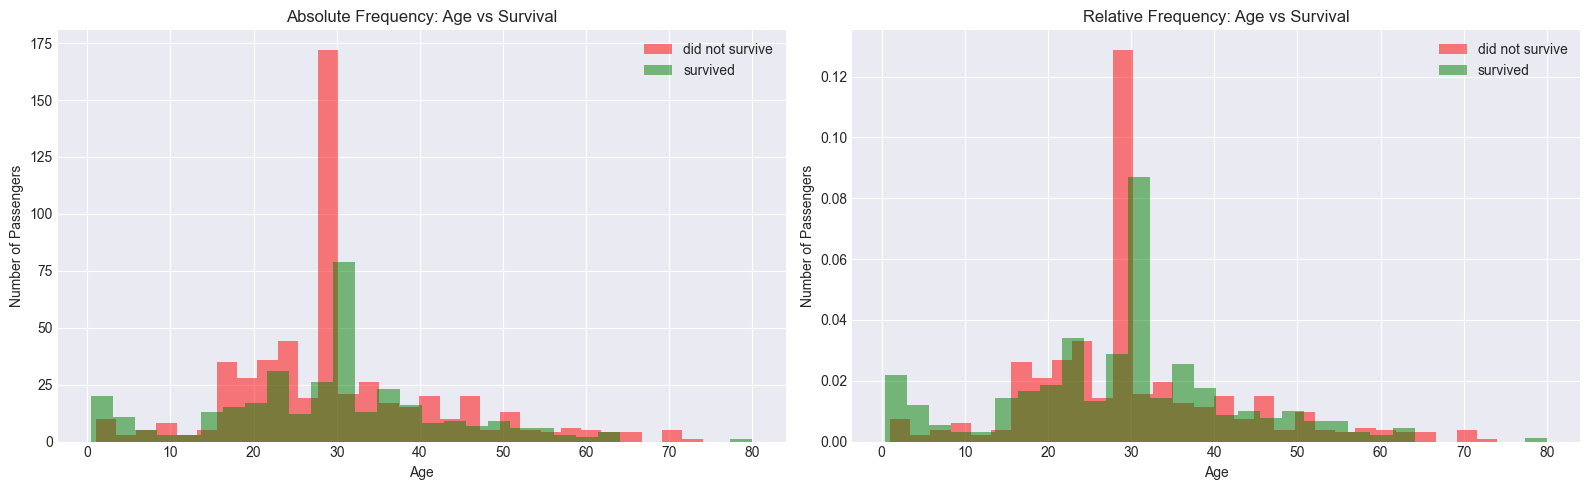

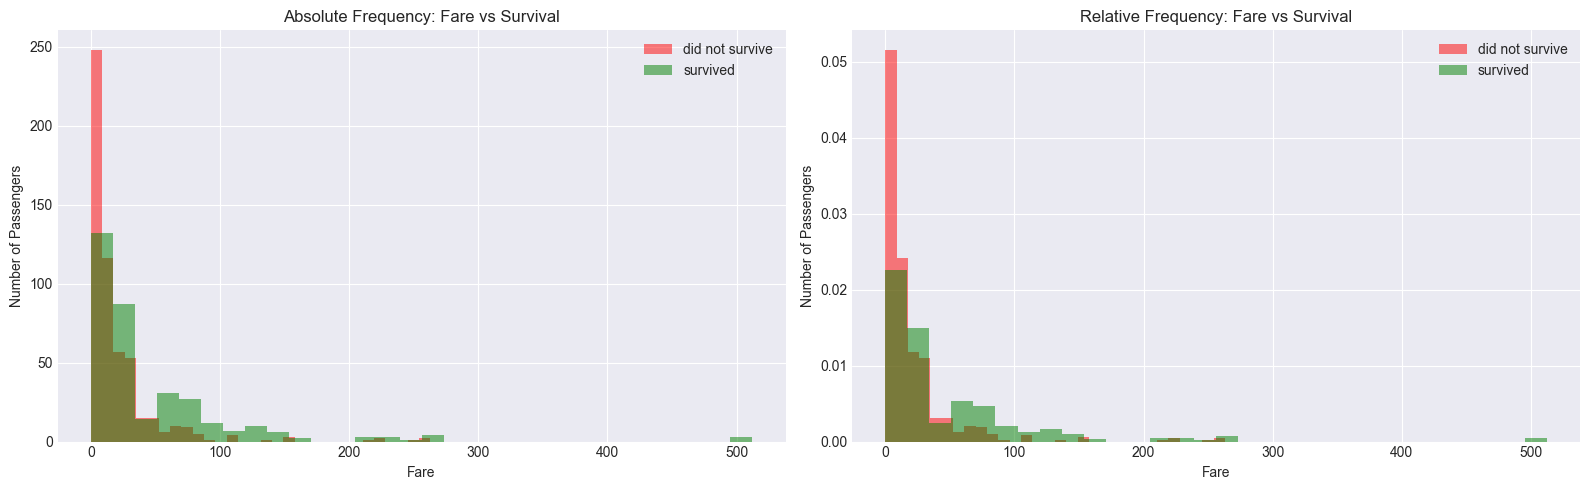

In [66]:
# split data into 2 dataframes, survived/did not survive to plot continuos features
eda2_df_1 = eda2_df[eda2_df['Survived'] == 1] # survived
eda2_df_0 = eda2_df[eda2_df['Survived'] == 0] # survived

# set plt style
plt.style.use('seaborn-v0_8-darkgrid')

# plot continuous features against survival
for feature in ['Age', 'Fare']:
    # Create a figure with 2 subplots (1 row, 2 columns)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    for ax, density, frequency in ((ax1, False, 'Absolute'), (ax2, True, 'Relative')):

        ax.hist(eda2_df_0[feature], bins=30, alpha=0.5, color='red', label='did not survive', density=density)
        ax.hist(eda2_df_1[feature], bins=30, alpha=0.5, color='green', label='survived', density=density)
        ax.set_title(f'{frequency} Frequency: {feature} vs Survival')
        ax.set_ylabel('Number of Passengers')
        ax.set_xlabel(feature)
        ax.legend()


    plt.tight_layout() # Prevents labels from overlapping
    plt.show()

#### Plots comments

Age vs survival: It seems that the probability of surviving for children under 10 was higher. The peak around 30 is caused by the imputed values.

Fare vs survival: Low fares seem to correspond with lower chance of surviving. From roughly 50$ the rate of survival increases.

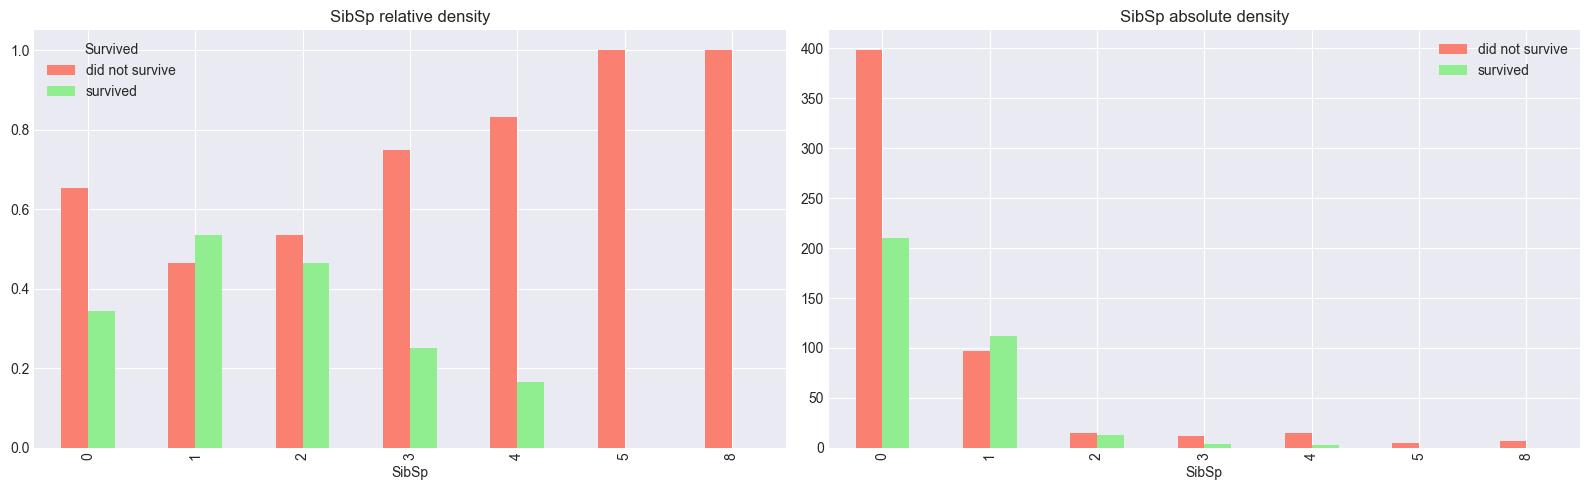

Survived,did not survive,survived
SibSp,,
0,398,210
1,97,112
2,15,13
3,12,4
4,15,3
5,5,0
8,7,0


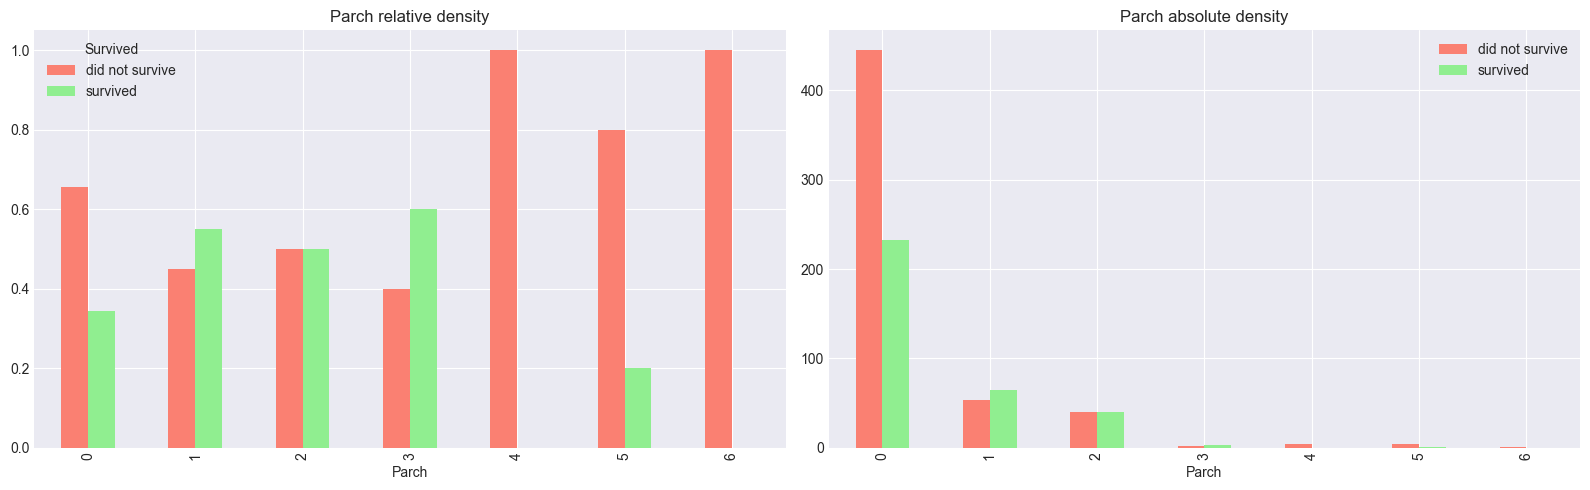

Survived,did not survive,survived
Parch,,
0,445,233
1,53,65
2,40,40
3,2,3
4,4,0
5,4,1
6,1,0


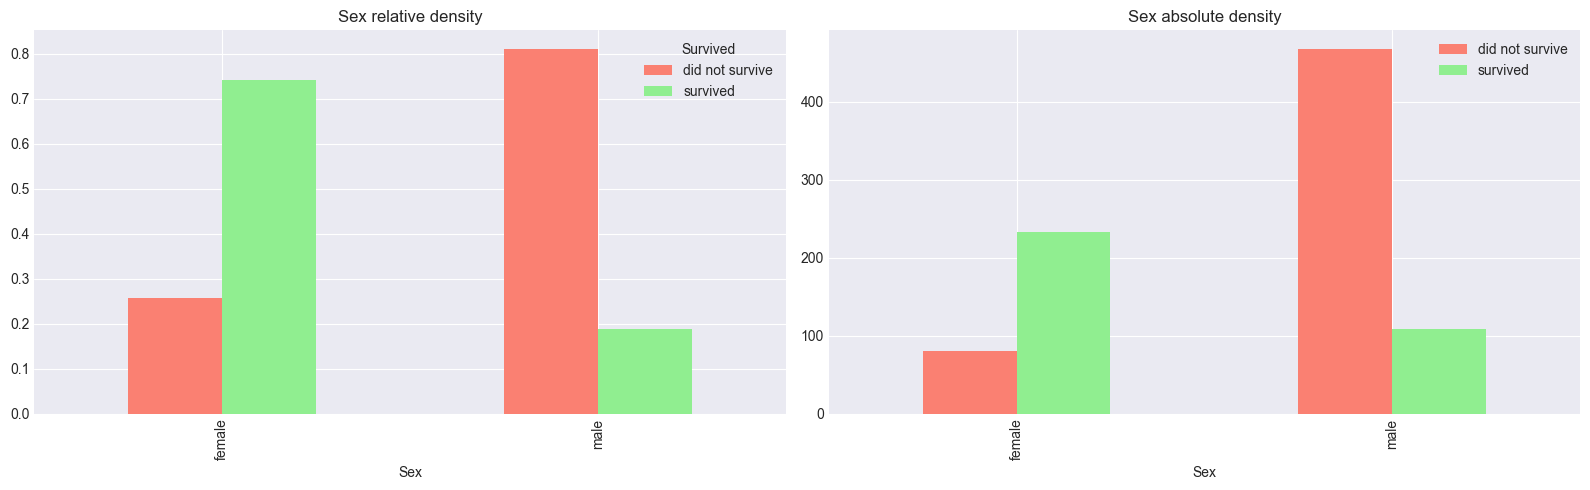

Survived,did not survive,survived
Sex,,
female,81,233
male,468,109


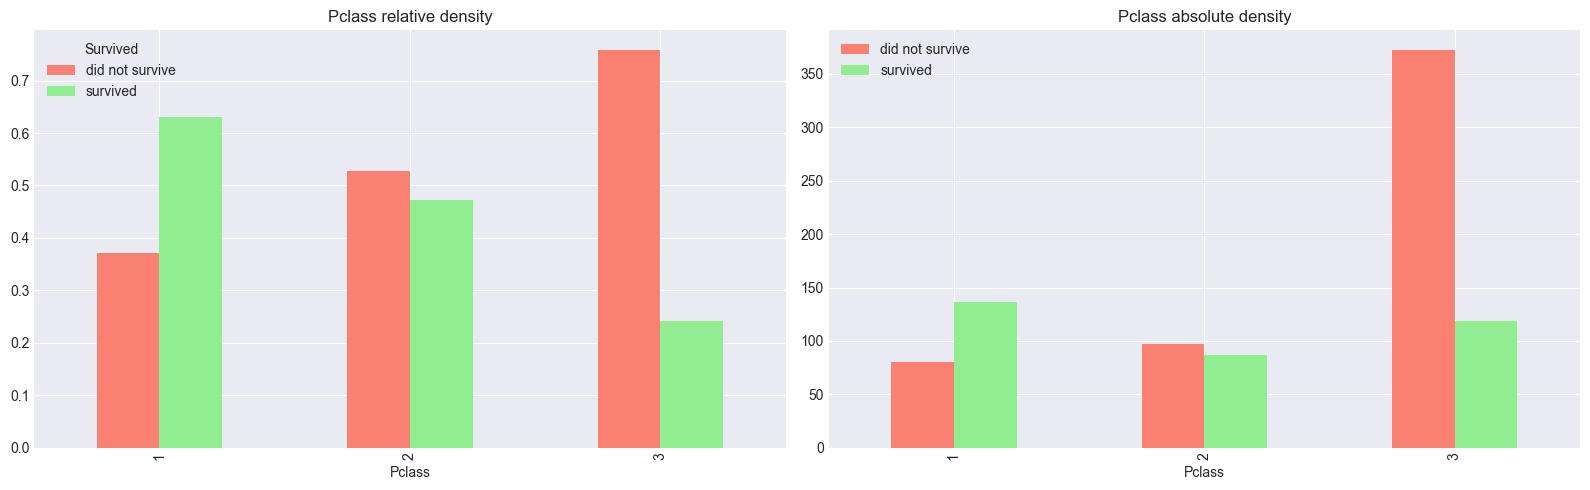

Survived,did not survive,survived
Pclass,,
1,80,136
2,97,87
3,372,119


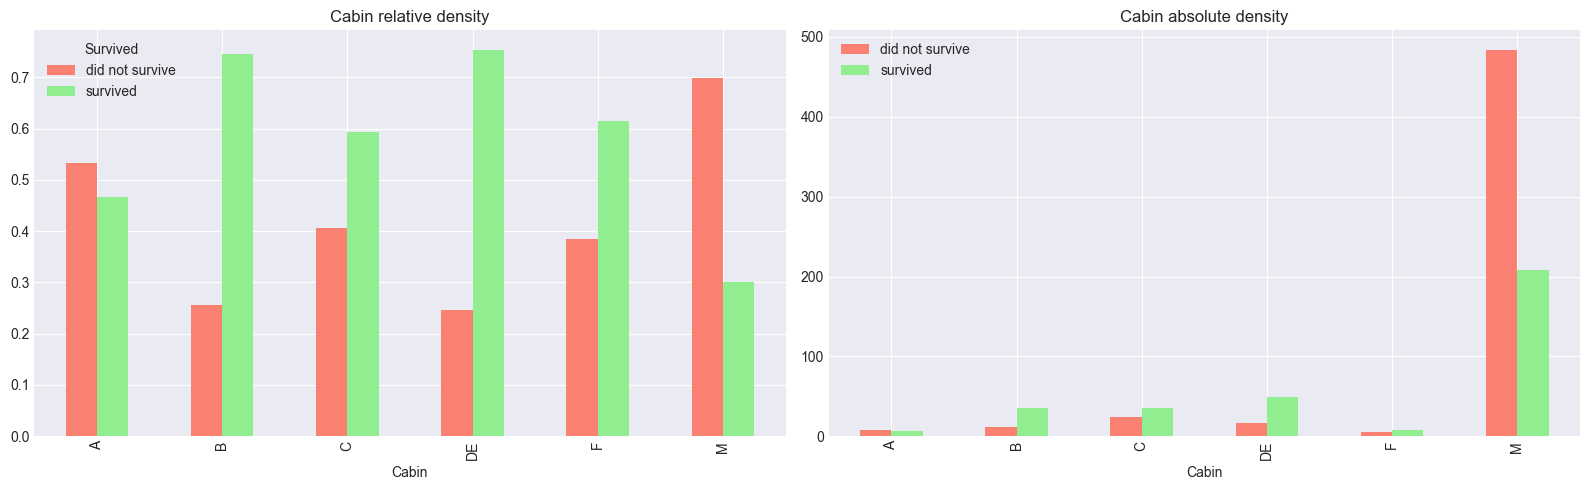

Survived,did not survive,survived
Cabin,,
A,8,7
B,12,35
C,24,35
DE,16,49
F,5,8
M,484,208


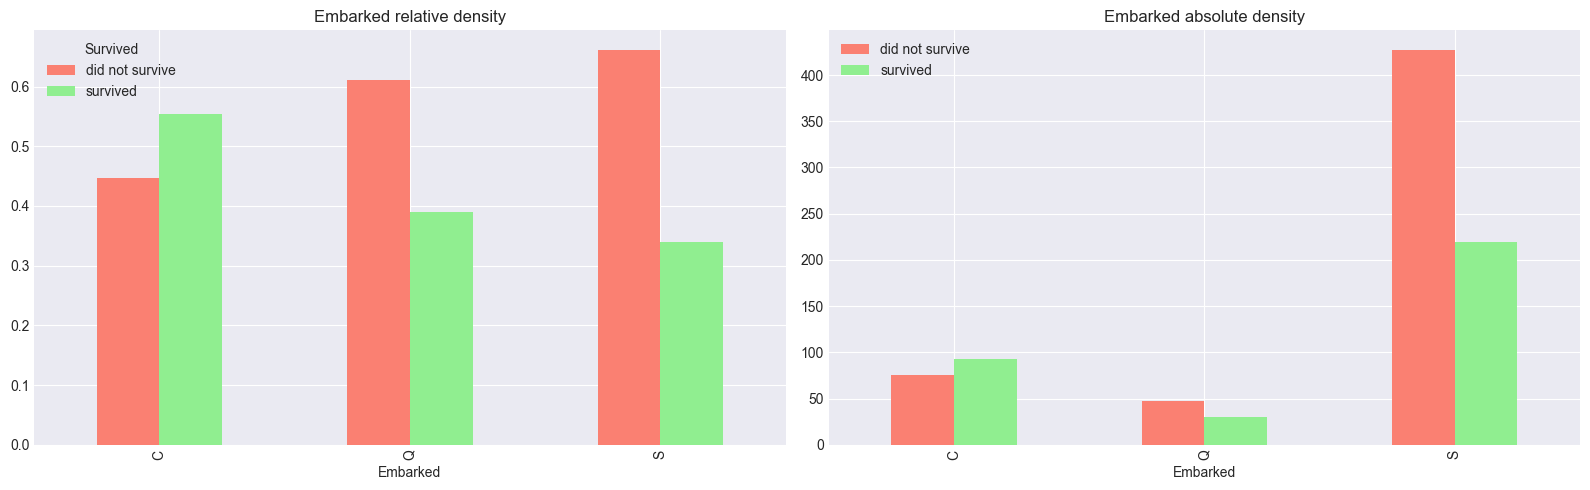

Survived,did not survive,survived
Embarked,,
C,75,93
Q,47,30
S,427,219


In [67]:
# plot discrete features against survival
for feature in ['SibSp', 'Parch', 'Sex', 'Pclass', 'Cabin', 'Embarked']:
        # instantiate figure object
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

        for type, axis, is_relative in (('index', ax1, 'relative'), (False, ax2, 'absolute')):            
            ct = pd.crosstab(eda2_df[feature], eda2_df['Survived'], normalize=type)
            ct.rename(columns= {0:'did not survive', 1: 'survived'},
            inplace=True)

            ct.plot(kind='bar',
                ax=axis,
                color=['salmon', 'lightgreen'],            
                title=f'{feature} {is_relative} density'
                )  
            

        plt.legend()
        plt.tight_layout()
        plt.show()
        display(ct)

#### Plots comments

SibSp: Passengers with one or two sibling/spouse where roughly equally likeable to survive/not survive. All other combinations where more likely to not survive. Check number of observations per group, it might be convinient to make a group over 3 or 4 sibsp. I was inclined to group SibSp observations above a value 0f 2, however, I find it significant that out of 13 cases, none survived above 4. Clip it at 5.  
`df['Parch_capped'] = df['SibSp'].clip(upper=5)` 

Parch: Passengers with one, two or three parent/children where roughly equally likeable to survive/not survive. All other combinations where more likely to not survive. Check number of observations per group, it might be convinient to make a group over 4 parch. Clip it at 4  
`df['Parch_capped'] = df['Parch'].clip(upper=4)`

Sex: Females had a higher probability of survival.

Pclass: The probability of survival was highest among class 1. Class 2 has roughly the same probability between survive/did not survive. Class 3 had the lowest probability of survival, passengers were 3.5 times more likely to not survive than survive in that class.

Cabin: Cabins A and F have roughly the same survival rate. The missing category has the lowest survival rate. All other cabins have a positive survival rate. Group cabins D and E.

Embarked: C has a mild positive survival rate and Q a mild negative one. S survival rate is the lowest, roughly a third.

#### Plot histograms

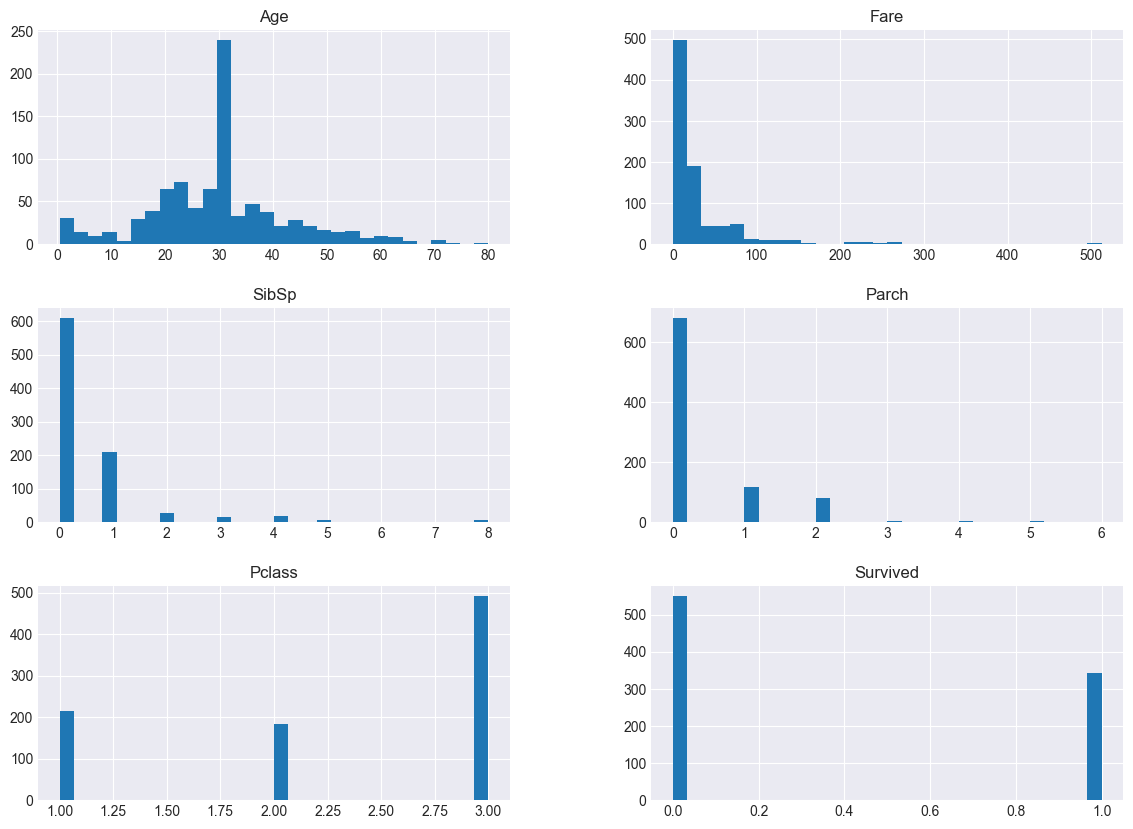

In [70]:
# quick histogram of numeric features
eda2_df.hist(figsize=(14,10), bins=30);

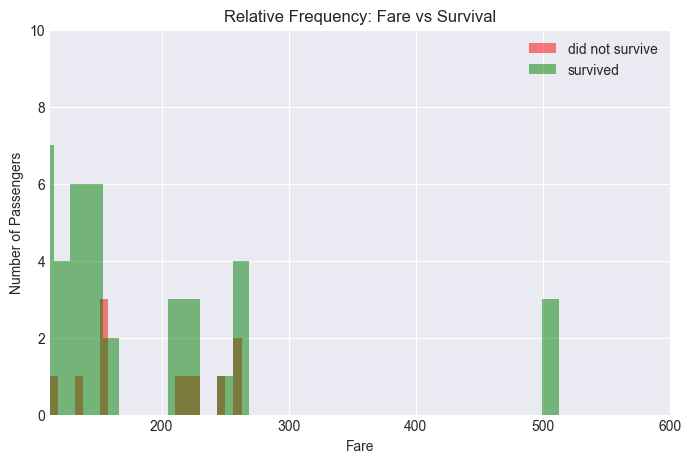

In [71]:
# zoom in on the tail of Fare feature to determine whether to clip outliers

# determine the required quantile
quantile = eda2_df['Fare'].quantile(0.95)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(eda2_df_0['Fare'], bins=40, alpha=0.5, color='red', label='did not survive')
ax.hist(eda2_df_1['Fare'], bins=40, alpha=0.5, color='green', label='survived')
ax.set_title('Relative Frequency: Fare vs Survival')
ax.set_ylabel('Number of Passengers')
ax.set_xlabel('Fare')
ax.set(xlim=(quantile, 600),
       ylim=(0, 10))
ax.legend()

plt.show()

We can either cap it at 95th or 99th quantile and apply a log transformation or only apply the log transformation

#### Linear correlation between variables

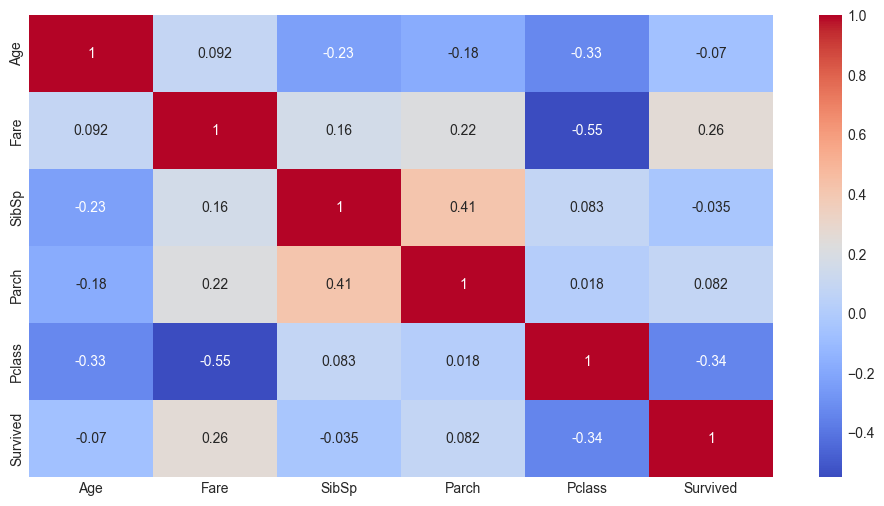

In [72]:
# only numeric features dataframe 
eda2_df_numeric = eda2_df.loc[:, ['Age', 'Fare', 'SibSp', 'Parch', 'Pclass', 'Survived']]

# build correlation matrix
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(eda2_df_numeric.corr(), annot=True, cmap='coolwarm', ax=ax)
plt.show()

#### Scatterplot continuous variables

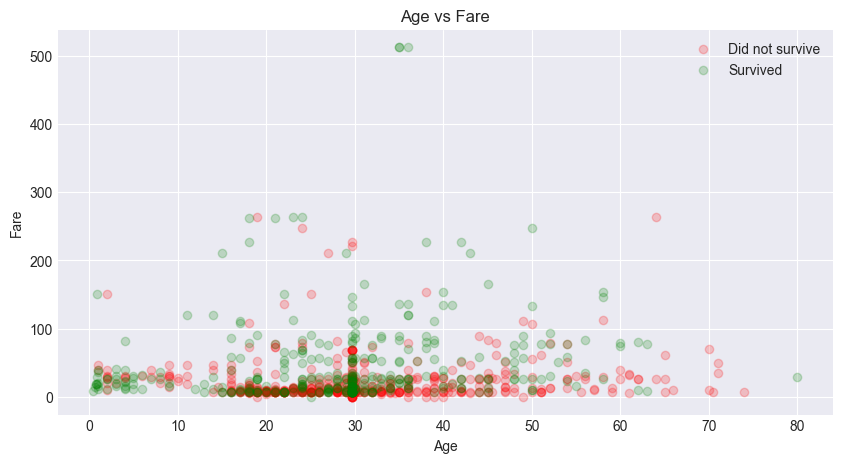

In [73]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(eda2_df_0['Age'], eda2_df_0['Fare'], color='red', alpha=0.2)
ax.scatter(eda2_df_1['Age'], eda2_df_1['Fare'], color='green', alpha=0.2)

ax.set(title='Age vs Fare',
       xlabel='Age',
       ylabel='Fare')

plt.legend(['Did not survive', 'Survived'])
plt.show()

#### Transformations to apply  
- age: Standardize  

- Fare: Apply log transformation

- SibSp: Clip at 5 and standardize 

- Parch: Clip at 4 and standardize  

- Pclass: One hot encode  

- Cabin: Group cabins D and E (on first transformation)  and One hot encode

I should've combined cabin groups through the first transformation. For that, the first EDA should've been more detailed. Maybe I should've concentrated both EDAs up front, decide what to transform first for the baseline models and what to leave for a second transformation.  
The idea was to do a basic Eda first to transform the bare minimum for the baseline. The problem is that I might miss certain transformations needed.